# Fake News Detection - End-to-End NLP Project

Team: Sabeur, Philippe, Joao  
Duration: 3 days

We're building a small classifier that reads a news headline and decides if it's fake (0) or real (1). The whole thing lives in this one notebook so anyone on the team can open it and follow along.

---

## Who does what

| Member | Role | What they hand off |
|--------|------|---------------------|
| Sabeur | Data & preprocessing | A clean dataset and a `clean_text()` function |
| Philippe | Features & modelling | A trained `model_pipeline` |
| Joao | Evaluation & predictions | Final metrics and `submission.csv` |

### How the 3 days are split

**Day 1 - getting the data ready (Sabeur, with Philippe joining at the end)**
- Morning: load the data, look around, fix the obvious issues, do a bit of EDA
- Afternoon: write and test the preprocessing pipeline
- End of day: Philippe sets up a TF-IDF + baseline model just to sanity-check the cleaned data

**Day 2 - modelling (Philippe, then Joao)**
- Morning: train Logistic Regression, Naive Bayes and SVM on TF-IDF features
- Afternoon: tune hyperparameters with cross-validation, pick the best one
- End of day: Joao wires up the train/val split and the evaluation helpers

**Day 3 - testing and wrap-up (Joao, then everyone)**
- Morning: run the trained model on `test.csv` and generate predictions
- Early afternoon: error analysis - look at what we got wrong and why
- Late afternoon: review together, finalise the submission, prep the slides

### A few rules so we don't step on each other

- Sabeur's `clean_text()` is the only preprocessing function. Philippe and Joao reuse it as-is.
- The vectorizer and model live inside one sklearn `Pipeline` that Philippe builds. Joao reuses that exact object - no retraining.
- On test data we only call `.transform()` and `.predict()`. Never `.fit()` - that would be data leakage.

### The pipeline at a glance

```
raw csv  ->  clean  ->  preprocess  ->  vectorise  ->  train  ->  evaluate  ->  predict
             Sabeur     Sabeur          Philippe       Philippe   Joao         Joao
```

---

## Setup

All the imports we share across the notebook. If you need something specific to your section, add it inside that section.

In [1]:
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

import joblib

# Run these once, then comment them out
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt')

RANDOM_STATE = 42
pd.set_option('display.max_colwidth', 120)

---
# 1. The data

Two files in `dataset/`:

- `training_data_lowercase.csv` - has `label` and `headline`. Labels are 0 (fake) or 1 (real). This is what we train on.
- `testing_data_lowercase_nolabels.csv` - just `headline`. No labels - this is what we have to predict.

---
# 2. Loading and cleaning the data - Sabeur

In [2]:
TRAIN_PATH = 'dataset/training_data_lowercase.csv'
TEST_PATH = 'dataset/testing_data_lowercase_nolabels.csv'

# The files are tab-separated and have no header row
df_train = pd.read_csv(TRAIN_PATH, sep='\t', header=None, names=['label', 'headline'])
df_test = pd.read_csv(TEST_PATH, sep='\t', header=None, names=['headline'])

print('Train shape:', df_train.shape)
print('Test  shape:', df_test.shape)
df_train.head()

Train shape: (34152, 2)
Test  shape: (9984, 1)


,label,headline
0,0,donald trump sends out embarrassing new year‚s eve message; this is disturbing
1,0,drunk bragging trump staffer started russian collusion investigation
2,0,sheriff david clarke becomes an internet joke for threatening to poke people ‚in the eye‚
3,0,trump is so obsessed he even has obama‚s name coded into his website (images)
4,0,pope francis just called out donald trump during his christmas speech


In [3]:
print('Missing in train:')
print(df_train.isna().sum())
print('\nMissing in test:')
print(df_test.isna().sum())

n_dup = df_train.duplicated().sum()
print(f'\nDuplicate rows in train: {n_dup}')
df_train = df_train.drop_duplicates().reset_index(drop=True)

df_train['label'] = df_train['label'].astype(int)
df_train['headline'] = df_train['headline'].astype(str)
df_test['headline'] = df_test['headline'].astype(str)

df_train.info()

Missing in train:
label       0
headline    0
dtype: int64

Missing in test:
headline    0
dtype: int64

Duplicate rows in train: 1946
<class 'pandas.DataFrame'>
RangeIndex: 32206 entries, 0 to 32205
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   label     32206 non-null  int64
 1   headline  32206 non-null  str  
dtypes: int64(1), str(1)
memory usage: 503.3 KB


## 2.1 A quick look at the data (EDA) - Sabeur

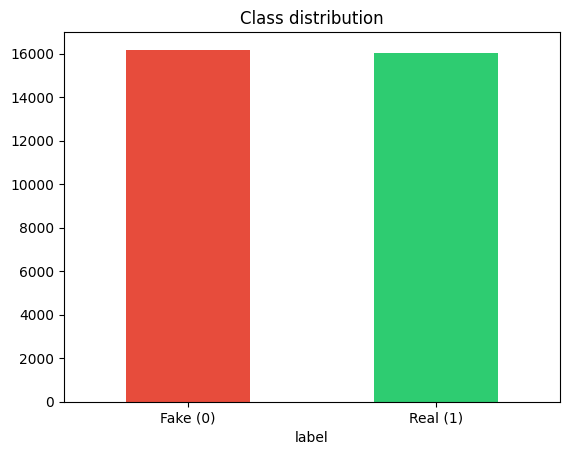

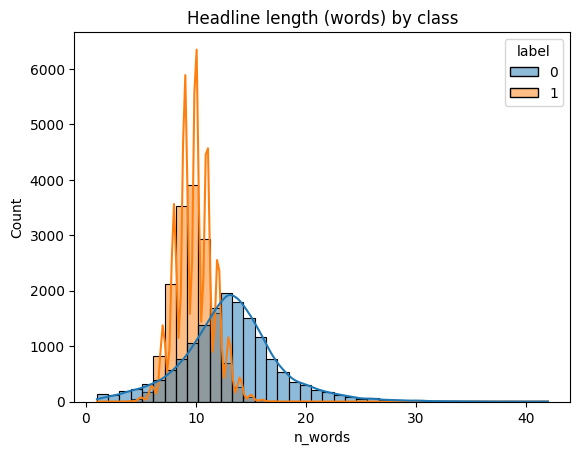

In [4]:
# How balanced are the two classes?
ax = df_train['label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['Fake (0)', 'Real (1)'], rotation=0)
ax.set_title('Class distribution')
plt.show()

# How long are the headlines, and does it differ by class?
df_train['n_words'] = df_train['headline'].str.split().str.len()
sns.histplot(data=df_train, x='n_words', hue='label', bins=40, kde=True)
plt.title('Headline length (words) by class')
plt.show()

---
# 3. Preprocessing - Sabeur

In [5]:
STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
PUNCT_RE = re.compile(f'[{re.escape(string.punctuation)}0-9]')


def clean_text(text: str) -> str:
    """Lowercase, strip punctuation/digits, drop stopwords, lemmatise."""
    text = text.lower()
    text = PUNCT_RE.sub(' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# Quick check on a noisy example
clean_text("Donald Trump sends out EMBARRASSING tweets!!! #fakenews")

'donald trump sends embarrassing tweet fakenews'

In [6]:
df_train['processed_text'] = df_train['headline'].apply(clean_text)
df_test['processed_text'] = df_test['headline'].apply(clean_text)

df_train[['headline', 'processed_text', 'label']]

,headline,processed_text,label
0,donald trump sends out embarrassing new year‚s eve message; this is disturbing,donald trump sends embarrassing new year‚s eve message disturbing,0
1,drunk bragging trump staffer started russian collusion investigation,drunk bragging trump staffer started russian collusion investigation,0
2,sheriff david clarke becomes an internet joke for threatening to poke people ‚in the eye‚,sheriff david clarke becomes internet joke threatening poke people ‚in eye‚,0
3,trump is so obsessed he even has obama‚s name coded into his website (images),trump obsessed even obama‚s name coded website image,0
4,pope francis just called out donald trump during his christmas speech,pope francis called donald trump christmas speech,0
...,...,...,...
32201,tears in rain as thais gather for late king's funeral,tear rain thai gather late king funeral,1
32202,pyongyang university needs non-u.s. teachers as travel ban leaves staff shortages,pyongyang university need non teacher travel ban leaf staff shortage,1
32203,philippine president duterte to visit japan ahead of key regional summits,philippine president duterte visit japan ahead key regional summit,1
32204,japan's abe may have won election\tbut many don't want him as pm,japan abe may election many want pm,1


---
# 4. Feature engineering - Philippe

In [7]:
# Define pipelines for different vectorizer + classifier combinations (6 combinations)
pipelines = {
    "BoW + Naive Bayes": Pipeline([
        ("vec", CountVectorizer()), 
        ("clf", MultinomialNB())
    ]),
    "TF-IDF + Naive Bayes": Pipeline([
        ("vec", TfidfVectorizer()), 
        ("clf", MultinomialNB())
    ]),
    "BoW + Logistic Reg": Pipeline([
        ("vec", CountVectorizer()), 
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "TF-IDF + Logistic Reg": Pipeline([
        ("vec", TfidfVectorizer()), 
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "TF-IDF + Random Forest": Pipeline([
        ("vec", TfidfVectorizer()), 
        ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    "TF-IDF + Linear SVM": Pipeline([
        ("vec", TfidfVectorizer()), 
        ("clf", LinearSVC(random_state=42))
    ])
}

---
# 5. Training the models - Philippe

## Train / Test Split

In [8]:
X_data = df_train['processed_text']
y_data = df_train['label']

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.20, random_state=42)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows\n")

Train: 25764 rows | Test: 6442 rows



## Train and evaluate Pipelines, check overfitting

In [9]:
print("Testing combinations pipelines (Checking Train vs Test Accuracy)...\n")
best_baseline_acc = 0

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, pipe.predict(X_train))
    acc_test = accuracy_score(y_test, pipe.predict(X_test))
    
    print(f"[{name}]")
    print(f"   -> Train Acc: {acc_train:.4f} | Test Acc: {acc_test:.4f}")
    
    if acc_test > best_baseline_acc:
        best_baseline_acc = acc_test
        best_baseline_name = name

print(f"\n-----> BEST BASELINE COMBINATION: {best_baseline_name} ({best_baseline_acc:.4f})")

Testing combinations pipelines (Checking Train vs Test Accuracy)...

[BoW + Naive Bayes]
   -> Train Acc: 0.9499 | Test Acc: 0.9334
[TF-IDF + Naive Bayes]
   -> Train Acc: 0.9490 | Test Acc: 0.9319
[BoW + Logistic Reg]
   -> Train Acc: 0.9757 | Test Acc: 0.9362
[TF-IDF + Logistic Reg]
   -> Train Acc: 0.9550 | Test Acc: 0.9337
[TF-IDF + Random Forest]
   -> Train Acc: 1.0000 | Test Acc: 0.9135
[TF-IDF + Linear SVM]
   -> Train Acc: 0.9880 | Test Acc: 0.9382

-----> BEST BASELINE COMBINATION: TF-IDF + Linear SVM (0.9382)


## Hyperparameter Tuning (GridSearchCV)

In [10]:
pipe_to_tune = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LinearSVC(random_state=42))
])

param_grid = {
    'vec__ngram_range': [(1, 1), (1, 2)],
    'vec__max_features': [None, 5000],
    'clf__C': [0.01, 0.05, 0.1, 0.5, 1, 10]
}

grid_search = GridSearchCV(pipe_to_tune, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

tuned_test_acc = accuracy_score(y_test, grid_search.predict(X_test))

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Tuned Model Test Accuracy: {tuned_test_acc:.4f}")

final_best_model = grid_search.best_estimator_

Best parameters found: {'clf__C': 1, 'vec__max_features': None, 'vec__ngram_range': (1, 2)}
Tuned Model Test Accuracy: 0.9429


## Export Pipeline

In [11]:
output_filename = 'pipeline_best_model.pkl'

with open(output_filename, 'wb') as file:
    pickle.dump(final_best_model, file)
    
print(f"\nDeliverable successfully saved as '{output_filename}'")


Deliverable successfully saved as 'pipeline_best_model.pkl'


---
# 6. Evaluation - Joao

Now that Philippe's model is trained, my job is to measure how well it actually works and understand where it makes mistakes.

Metrics I'll compute:
- **Accuracy** — overall % of correct predictions
- **Precision** — of the headlines predicted as Real, how many actually are?
- **Recall** — of all actual Real headlines, how many did we catch?
- **F1** — harmonic mean of Precision and Recall (best single-number summary)
- **Confusion Matrix** — visual breakdown of TP, TN, FP, FN

In [12]:
# Step 1: Load the model Philippe saved

with open('pipeline_best_model.pkl', 'rb') as f:
    model_pipeline = pickle.load(f)

print(" Model loaded successfully!")
print(f"Pipeline steps: {[step[0] for step in model_pipeline.steps]}")

 Model loaded successfully!
Pipeline steps: ['vec', 'clf']


In [13]:
# Step 2: Generate predictions on the validation set

y_pred = model_pipeline.predict(X_test)

print(f"Predictions generated: {len(y_pred)} samples")

Predictions generated: 6442 samples


In [14]:
#Step 3: Compute the core metrics

# accuracy_score: (correct predictions) / (total predictions)
acc = accuracy_score(y_test, y_pred)

# precision_score: of the headlines we predicted as Real (1),

prec = precision_score(y_test, y_pred)

# recall_score: of all the Real (1) headlines in the dataset,

rec = recall_score(y_test, y_pred)

# f1_score: combines precision and recall into one number.

f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("EVALUATION RESULTS")
print("=" * 40)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")

EVALUATION RESULTS
  Accuracy  : 0.9429  (94.29%)
  Precision : 0.9367
  Recall    : 0.9495
  F1 Score  : 0.9431


In [15]:
# Step 4: Full classification report

print("CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Fake News (0)', 'Real News (1)']
))

CLASSIFICATION REPORT
               precision    recall  f1-score   support

Fake News (0)       0.95      0.94      0.94      3233
Real News (1)       0.94      0.95      0.94      3209

     accuracy                           0.94      6442
    macro avg       0.94      0.94      0.94      6442
 weighted avg       0.94      0.94      0.94      6442



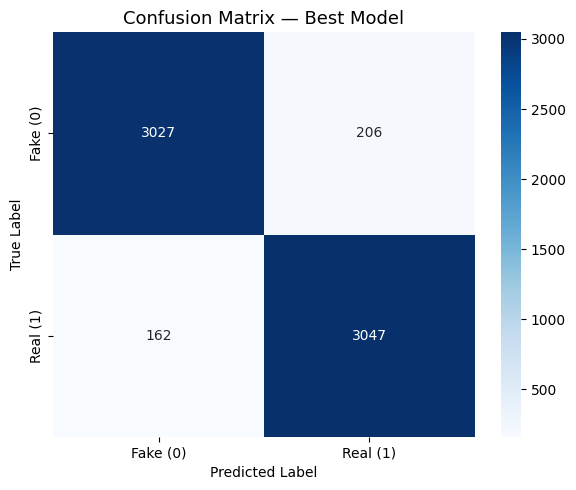

 Saved as 'confusion_matrix.png'


In [16]:
# Step 5: Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,                          
    fmt='d',                            
    cmap='Blues',                        
    xticklabels=['Fake (0)', 'Real (1)'],
    yticklabels=['Fake (0)', 'Real (1)'],
    ax=ax
)
ax.set_title('Confusion Matrix — Best Model', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(" Saved as 'confusion_matrix.png'")

In [17]:
# Step 6: Error analysis — look at what the model got wrong

eval_df = pd.DataFrame({
    'headline' : X_test.values,    # Original (unprocessed) headline text
    'true'     : y_test.values,    # Correct label (0 or 1)
    'predicted': y_pred            # What the model predicted
})

# Filter for rows where the model was wrong
misclassified = eval_df[eval_df['true'] != eval_df['predicted']]

print(f"Total misclassifications: {len(misclassified)} out of {len(eval_df)} "
      f"({len(misclassified)/len(eval_df)*100:.1f}%)")
print()

Total misclassifications: 368 out of 6442 (5.7%)



In [18]:
# False Negatives: model predicted Fake (0) but headline was actually Real (1)

false_negatives = misclassified[misclassified['true'] == 1].head(5)
print("=== Real headlines the model thought were FAKE (False Negatives) ===")
for _, row in false_negatives.iterrows():
    print(f"  '{row['headline']}'")
print()

=== Real headlines the model thought were FAKE (False Negatives) ===
  'san diego catholic diocese denounces parish called voting democrat mortal sin'
  'right advocate slam trump plan muslim immigrant refugee'
  'hillary clinton say donald trump unqualified president'
  'russia rt america register foreign agent'
  'biden tell baltic state take trump seriously'



In [19]:
# False Positives: model predicted Real (1) but headline was actually Fake (0)

false_positives = misclassified[misclassified['true'] == 0].head(5)
print("=== Fake headlines the model thought were REAL (False Positives) ===")
for _, row in false_positives.iterrows():
    print(f"  '{row['headline']}'")

=== Fake headlines the model thought were REAL (False Positives) ===
  'obamacare wheel slowly falling socialized healthcare train‚billions wasted'
  'kentucky republican introduce abortion ban'
  'senate republican dis trump badly‚they love tim kaine aren‚t afraid say'
  'democrat crushed bunch republican illinois backlash trump'
  'facebook user arrested ‚offensive‚ post syrian refugee ‚social medium abuse tolerated‚'


---
# 7. Predicting on the test set - Joao

Now we apply the model to the real test set — the one with no labels.
This is what we submit.

Key rules:
- Use Sabeur's `clean_text()` on the test headlines (same preprocessing as training)
- Use Philippe's already-fitted `model_pipeline` — **no refitting**
- Only call `.predict()` — never `.fit()` on test data

In [20]:
# Step 1: Verify the test data is ready

print(f"Test set size: {len(df_test)} headlines")
print()
print("Preview of test data:")
df_test[['headline', 'processed_text']].head()

Test set size: 9984 headlines

Preview of test data:


,headline,processed_text
2,copycat muslim terrorist arrested with assault weapons,copycat muslim terrorist arrested assault weapon
2,wow! chicago protester caught on camera admits violent activity was pre-planned: ‚it‚s not gonna be peaceful‚,wow chicago protester caught camera admits violent activity pre planned ‚it‚s gon na peaceful‚
2,germany's fdp look to fill schaeuble's big shoes,germany fdp look fill schaeuble big shoe
2,mi school sends welcome back packet warning kids against wearing u.s. flag to school,mi school sends welcome back packet warning kid wearing flag school
2,u.n. seeks 'massive' aid boost amid rohingya 'emergency within an emergency',seek massive aid boost amid rohingya emergency within emergency


In [21]:
# Step 2: Generate predictions


test_predictions = model_pipeline.predict(df_test['processed_text'])

# Quick sanity check: distribution of predictions
unique, counts = np.unique(test_predictions, return_counts=True)
print(f"Predictions generated: {len(test_predictions)}")
print()
for label, count in zip(unique, counts):
    name = 'Fake' if label == 0 else 'Real'
    print(f"  Predicted {name} ({label}): {count} headlines ({count/len(test_predictions)*100:.1f}%)")

Predictions generated: 9984

  Predicted Fake (0): 4752 headlines (47.6%)
  Predicted Real (1): 5232 headlines (52.4%)


---
# 8. Final output - Joao

Two deliverables:
1. `submission.csv` — predictions for every test headline, in order
2. `model_pipeline.joblib` — the saved pipeline for reproducibility

In [22]:
# Deliverable 1: submission.csv


submission = pd.DataFrame({'prediction': test_predictions})

submission.to_csv('submission.csv', index=False)

print(" submission.csv saved!")
print()
print("Preview:")
print(submission.head(10))

 submission.csv saved!

Preview:
   prediction
0           0
1           0
2           0
3           0
4           1
5           0
6           1
7           0
8           1
9           1


In [23]:
# Deliverable 2: model_pipeline.joblib

joblib.dump(model_pipeline, 'model_pipeline.joblib')

print(" model_pipeline.joblib saved!")

 model_pipeline.joblib saved!


In [24]:
# Final Summary

print("=" * 55)
print("FAKE NEWS DETECTION — FINAL SUMMARY")
print("=" * 55)
print()
print("Dataset")
print(f"  Training samples   : {len(X_train)}")
print(f"  Validation samples : {len(X_test)}")
print(f"  Test samples       : {len(df_test)}")
print()
print("Best Model")
print(f"  Pipeline           : TF-IDF + Linear SVM (tuned with GridSearchCV)")
print(f"  Validation Accuracy: {acc*100:.2f}%")
print(f"  Precision          : {prec:.4f}")
print(f"  Recall             : {rec:.4f}")
print(f"  F1 Score           : {f1:.4f}")
print()
print("Output files")
print("   submission.csv         → Test set predictions (0=Fake, 1=Real)")
print("   model_pipeline.joblib  → Saved model for reproducibility")
print("   confusion_matrix.png   → Confusion matrix chart")

FAKE NEWS DETECTION — FINAL SUMMARY

Dataset
  Training samples   : 25764
  Validation samples : 6442
  Test samples       : 9984

Best Model
  Pipeline           : TF-IDF + Linear SVM (tuned with GridSearchCV)
  Validation Accuracy: 94.29%
  Precision          : 0.9367
  Recall             : 0.9495
  F1 Score           : 0.9431

Output files
   submission.csv         → Test set predictions (0=Fake, 1=Real)
   model_pipeline.joblib  → Saved model for reproducibility
   confusion_matrix.png   → Confusion matrix chart


---
# 9. Wrap-up and ideas for later

What we ended up with: a small, reproducible pipeline that cleans headlines, turns them into TF-IDF features, runs them through a classifier, and spits out predictions for the unlabelled test set.

Things we could try if we had more time:
- Word embeddings (Word2Vec, GloVe) instead of TF-IDF.
- A pretrained transformer (BERT or RoBERTa) for the heavy-lifting baseline.
- A tiny Streamlit app so anyone can paste a headline and get a verdict.
- Tracking how accuracy holds up over time or across topics.

Teamwork makes the model work.